# Define Chain?
A Chain is a sequence of steps connected together.

# Think of it like a pipeline:

Input → Step 1 → Step 2 → Step 3 → Output

# Example:

Question
   ↓
Prompt Template
   ↓
LLM (ChatGPT)
   ↓
Output Parser
   ↓
Final Answer

This whole flow is called a Chain.

# Why do we need Chains?

Without a chain:

question = "What is AI?"

prompt = f"Answer: {question}"

response = llm.invoke(prompt)

print(response.content)

Everything is written manually.



# Code

In [ ]:
# from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI()

prompt = ChatPromptTemplate.from_template(
    "Explain {topic} in simple words."
)

chain = prompt | llm

result = chain.invoke({"topic": "Python"})

print(result.content)

# Chain ki zarurat (Why)?

Maan lo tum AI app bana rahe ho.

User question deta hai:

"What is Python?"

Ab tumhe:

Question lena hai

Prompt banana hai

LLM ko bhejna hai

Answer lena hai

Output format karna hai

Har step ko alag-alag manually likhna tedious ho jata hai.

Isliye LangChain me hum sab steps ko connect kar dete hain:

Question
   ↓
Prompt Template
   ↓
LLM
   ↓
Output Parser
   ↓
Final Answer

Ye connected flow hi Chain hai.

# Sequential Chain

Sequential Chain ek aisi chain hai jahan steps ek ke baad ek (sequence mein) execute hote hain.

Step 1 → Step 2 → Step 3 → Final Output

Ek step ka output next step ka input ban jata hai.

# Why use Sequential Chain?

Agar ek bada task ko chhote-chhote steps mein todna ho.

Instead of:

Topic → LLM → Final Blog

You do:

Topic
  ↓
Create Outline
  ↓
Write Content
  ↓
Proofread
  ↓
Final Blog

Result usually better and more organized hota hai.

# Example

Input:

"Artificial Intelligence"

Flow:

AI
 ↓
Generate Outline
 ↓
1. Introduction
2. Types
3. Applications

 ↓
Write Article
 ↓
Full Article

 ↓
Summarize
 ↓
Short Summary

# Code

Suppose:

1. Step 1 → Generate a blog title
2. Step 2 → Write a blog using that title


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI()

# Step 1: Generate title
title_prompt = ChatPromptTemplate.from_template(
    "Generate a catchy blog title about {topic}"
)

# Step 2: Generate blog from title
blog_prompt = ChatPromptTemplate.from_template(
    "Write a short blog on this title: {title}"
)

# Chain 1
title_chain = title_prompt | llm

# Get title
title = title_chain.invoke({"topic": "Artificial Intelligence"}).content

# Chain 2
blog_chain = blog_prompt | llm

# Use title as input
blog = blog_chain.invoke({"title": title})



print("Title:", title)
print("\nBlog:\n", blog.content)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI()

title_prompt = ChatPromptTemplate.from_template(
    "Generate a blog title about {topic}"
)

blog_prompt = ChatPromptTemplate.from_template(
    "Write a blog on {title}"
)

title_chain = title_prompt | llm | StrOutputParser()

chain = (
    title_chain
    | RunnableLambda(
        lambda title: {"title": title}
    )
    | blog_prompt
    | llm
    | StrOutputParser()
)

result = chain.invoke({"topic": "AI"})

print(result)

# Parallel Chain

Parallel Chain mein multiple tasks ek saath (simultaneously) run hote hain.

Parallel Chain:

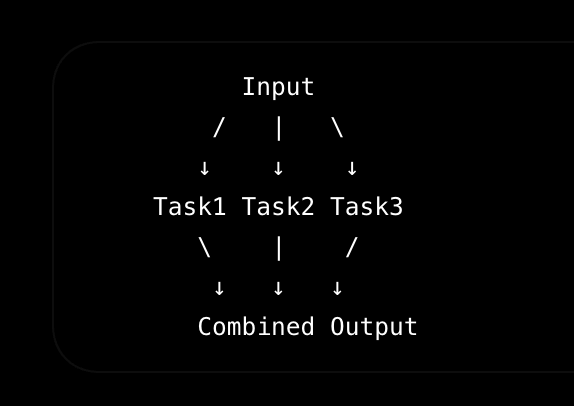

# Why use Parallel Chain?

Jab ek hi input se multiple outputs chahiye ho.

Example:

Input:

Artificial Intelligence

Ek saath:

Summary generate karo,
Advantages batao,
Disadvantages batao

Ye teenon tasks independent hain, isliye parallel mein run kar sakte hain.

# Code

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel

llm = ChatOpenAI()

summary_chain = (
    ChatPromptTemplate.from_template(
        "Give a short summary of {topic}"
    )
    | llm
    | StrOutputParser()
)

pros_chain = (
    ChatPromptTemplate.from_template(
        "Give advantages of {topic}"
    )
    | llm
    | StrOutputParser()
)

cons_chain = (
    ChatPromptTemplate.from_template(
        "Give disadvantages of {topic}"
    )
    | llm
    | StrOutputParser()
)

parallel_chain = RunnableParallel(
    summary=summary_chain,
    pros=pros_chain,
    cons=cons_chain
)

result = parallel_chain.invoke(
    {"topic": "Artificial Intelligence"}
)

print(result)

# Conditional Chain
onditional Chain mein next step condition ke basis par decide hota hai.

Matlab:

If condition is True
      ↓
   Chain A

Else
      ↓
   Chain B

Har baar same path follow nahi hota.

# Why use Conditional Chain?

Example:

Question: "What is Python?"
        ↓
Programming Question
        ↓
Coding Expert Chain

Question: "What is Diabetes?"
        ↓
Medical Question
        ↓
Medical Expert Chain



# Code


In [ ]:
from langchain_core.runnables import RunnableBranch
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

llm = ChatOpenAI()

coding_chain = (
    ChatPromptTemplate.from_template(
        "Answer as a programming expert: {question}"
    )
    | llm
)

medical_chain = (
    ChatPromptTemplate.from_template(
        "Answer as a medical expert: {question}"
    )
    | llm
)

general_chain = (
    ChatPromptTemplate.from_template(
        "Answer: {question}"
    )
    | llm
)

chain = RunnableBranch(
    (
        lambda x: "python" in x["question"].lower(),
        coding_chain
    ),
    (
        lambda x: "diabetes" in x["question"].lower(),
        medical_chain
    ),
    general_chain
)

result = chain.invoke(
    {"question": "What is Python?"}
)

print(result.content)

# 1. RunnableLambda

RunnableLambda normal Python function ko LangChain chain ka part banata hai.



In [ ]:
from langchain_core.runnables import RunnableLambda

chain = RunnableLambda(
    lambda x: x + "!"
)

print(chain.invoke("Hello"))

# Why?

Jab chain ke beech mein custom Python logic lagana ho.

2. RunnableParallel

Multiple chains ko ek saath run karta hai.

Input
  ├── Chain A
  ├── Chain B
  └── Chain C

  

In [ ]:
from langchain_core.runnables import RunnableParallel, RunnableLambda

chain = RunnableParallel(
    square=RunnableLambda(lambda x: x * x),
    cube=RunnableLambda(lambda x: x * x * x)
)

print(chain.invoke(5))

# 3. RunnableBranch
What?

Condition check karke decide karta hai kaunsi chain run hogi.

Input
  ↓
Condition
  ↓
Chain A or Chain B

In [ ]:
from langchain_core.runnables import RunnableBranch, RunnableLambda

chain = RunnableBranch(
    (
        lambda x: x > 10,
        RunnableLambda(lambda x: "Greater than 10")
    ),
    RunnableLambda(lambda x: "10 or less")
)

print(chain.invoke(15))
print(chain.invoke(5))